# Logit Lens: Qwen3-8B on iGSM (Local)

Apply unembedding (W_U) to the residual stream at every layer
to see if/when the correct answer emerges before generation.

In [2]:
import sys
sys.path.insert(0, "iGSM")

import os
os.environ["TRANSFORMERS_OFFLINE"] = "0"
os.environ["HF_DATASETS_OFFLINE"] = "0"
os.environ["HF_HUB_OFFLINE"] = "0"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "0"

import json
import glob

import matplotlib.pyplot as plt
import torch
import numpy as np
from transformer_lens import HookedTransformer


Matplotlib is building the font cache; this may take a moment.
/Users/marcin.mazur/repos/physics_of_lms_part2.1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = HookedTransformer.from_pretrained("Qwen/Qwen3-8B", trust_remote_code=True)


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer


In [17]:
PROBLEMS = [
    {
        "system_prompt": (
            "You are a math assistant solving word problems. "
            "When you have your final answer, output it exactly in the format: Answer: <your answer>."
        ),
        "problem": " The number of each Engineering Campus's Shoppers Value Foods equals 10. The number of each Shoppers Value Foods's Trail Mix equals 4. The number of each Price Rite's Trail Mix equals 4. The number of each Technical College District's Price Rite equals 9 times as much as each Trail Mix's Ingredient. The number of each Engineering Campus's Price Rite equals 9 times as much as each Price Rite's Trail Mix. The number of each Yogurt Covered Raisins's Chicken Wing equals 13. The number of each Yogurt Covered Raisins's Sausage equals the sum of each Engineering Campus's Shoppers Value Foods and each Engineering Campus's Supermarket. The number of each Price Rite's Yogurt Covered Raisins equals 21. How many Trail Mix does Price Rite have?",
        "ground_truth": 4,
    },
    {
        "system_prompt": (
            "You are a math assistant solving word problems. "
            "When you have your final answer, output it exactly in the format: Answer: <your answer>."
        ),
        "problem": (
            " The number of each Cookies's Barley equals 7. "
            "The number of each Blue Apron's Cookies equals 12. "
            "The number of each Danishes's Wild Rice equals 4 more than each Cookies's Barley. "
            "The number of each Blue Apron's Danishes equals 9. "
            "How many Ingredient does Blue Apron have?"
        ),
        "ground_truth": 22,
    },
    {
        "system_prompt": (
            "You are a math assistant solving word problems. "
            "When you have your final answer, output it exactly in the format: Answer: <your answer>."
        ),
        "problem": (
            " The number of each Duck Pond's Wolf equals 7. "
            "The number of each Raccoon's Epicentrals equals 5 times as much as each Phoenix Insectarium's Crane Courtyard. "
            "The number of each Insectarium de Montréal's Duck Pond equals 0. "
            "The number of each Wolf's Hypurals equals each Crane Courtyard's Wolf. "
            "The number of each Insectarium de Montréal's Crane Courtyard equals 17 more than the difference of each Raccoon's Haemal Spines and each Monkey's Epicentrals. "
            "The number of each Phoenix Insectarium's Kiwi House equals each Kiwi House's Raccoon. "
            "The number of each San Jose Insectarium's Duck Pond equals each Phoenix Insectarium's Enclosure. "
            "The number of each Phoenix Insectarium's Crane Courtyard equals 2. "
            "The number of each Crane Courtyard's Wolf equals each Duck Pond's Wolf. "
            "The number of each Kiwi House's Raccoon equals 9 times as much as the sum of each Raccoon's Haemal Spines, each Insectarium de Montréal's Duck Pond and each Monkey's Epicentrals. "
            "The number of each Phoenix Insectarium's Duck Pond equals 13. "
            "The number of each Monkey's Haemal Spines equals the sum of each Phoenix Insectarium's Duck Pond, each Duck Pond's Wolf and each Phoenix Insectarium's Crane Courtyard. "
            "The number of each Crane Courtyard's Raccoon equals each Wolf's Epicentrals. "
            "The number of each Monkey's Epicentrals equals 15. "
            "The number of each Wolf's Epicentrals equals each Insectarium de Montréal's Enclosure. "
            "The number of each Duck Pond's Monkey equals each San Jose Insectarium's Enclosure. "
            "The number of each Raccoon's Haemal Spines equals 16 times as much as each Monkey's Epicentrals. "
            "The number of each Raccoon's Hypurals equals the sum of each Raccoon's Epicentrals and each Monkey's Haemal Spines. "
            "How many Raccoon does Crane Courtyard have?"
        ),
        "ground_truth": 12,
    },
]
PROBLEMS=[PROBLEMS[0]]

prompts = []
tokens_list = []
gts = []
for p in PROBLEMS:
    messages = [
        {"role": "system", "content": p["system_prompt"]},
        {"role": "user", "content": p["problem"]},
    ]
    prompt = model.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    tokens = model.to_tokens(prompt)
    prompts.append(prompt)
    tokens_list.append(tokens)
    gts.append(p["ground_truth"])

for i, (t, gt) in enumerate(zip(tokens_list, gts)):
    print(f"Problem {i}: GT={gt}, tokens={t.shape[1]}")

Problem 0: GT=4, tokens=217


In [ ]:

CACHE_DIR = "logit_lens_caches"
os.makedirs(CACHE_DIR, exist_ok=True)

def run_logit_lens(model, tokens, gt, top_k=5, save_cache=True, cache_name=None):
    if cache_name is None:
        cache_name = f"p_gt{gt}"
    cache_path = os.path.join(CACHE_DIR, cache_name + ".pt")
    results_path = os.path.join(CACHE_DIR, cache_name + "_results.json")

    if os.path.exists(cache_path) and os.path.exists(results_path):
        print(f"  Loading cached: {cache_name}")
        with open(results_path) as f:
            per_layer = json.load(f)
        return per_layer, cache_path

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)

    resid_post_keys = sorted([k for k in cache.cache_dict if "hook_resid_post" in k])
    n_layers = len(resid_post_keys)
    last_pos = tokens.shape[1] - 1

    gt_tokens = model.to_tokens(str(gt))
    gt_token_id = gt_tokens[0, 1].item() if gt_tokens.shape[1] == 2 else gt_tokens[0, 0].item()

    per_layer = []
    resid_0 = cache["resid_pre", 0][0, last_pos]
    logits_0 = resid_0 @ model.W_U
    probs_0 = logits_0.softmax(dim=-1)
    top_probs_0, top_ids_0 = probs_0.topk(top_k)
    top_tokens_0 = [model.tokenizer.decode([tid.item()]) for tid in top_ids_0]
    per_layer.append({
        "layer": 0,
        "gt_prob": probs_0[gt_token_id].item(),
        "gt_logit": logits_0[gt_token_id].item(),
        "top_tokens": list(zip(top_tokens_0, [p.item() for p in top_probs_0])),
        "top_ids": [t.item() for t in top_ids_0],
        "gt_token_id": gt_token_id,
        "gt_token_str": model.tokenizer.decode([gt_token_id]),
    })
    for layer_idx in range(n_layers):
        resid = cache["resid_post", layer_idx][0, last_pos]
        logits = resid @ model.W_U
        probs = logits.softmax(dim=-1)

        top_probs, top_ids = probs.topk(top_k)
        top_tokens = [model.tokenizer.decode([tid.item()]) for tid in top_ids]

        per_layer.append({
            "layer": layer_idx + 1,
            "gt_prob": probs[gt_token_id].item(),
            "gt_logit": logits[gt_token_id].item(),
            "top_tokens": list(zip(top_tokens, [p.item() for p in top_probs])),
            "top_ids": [t.item() for t in top_ids],
            "gt_token_id": gt_token_id,
            "gt_token_str": model.tokenizer.decode([gt_token_id]),
        })

    if save_cache:
        torch.save(cache, cache_path)
        print(f"  Saved cache: {cache_path}")
        with open(results_path, "w") as f:
            json.dump(per_layer, f, indent=2)
        print(f"  Saved results: {results_path}")
        del cache

    return per_layer, cache_path


In [5]:
TOP_K = 3

all_results = []
all_cache_paths = []
for i, (tokens, gt) in enumerate(zip(tokens_list, gts)):
    print(f"Running logit lens on problem {i} (GT={gt})...")
    result, cache_path = run_logit_lens(model, tokens, gt, top_k=TOP_K)
    all_results.append(result)
    all_cache_paths.append(cache_path)

    max_entry = max(result, key=lambda x: x["gt_prob"])
    print(f"  GT token: '{result[0]['gt_token_str']}'")
    print(f"  Max GT prob: {max_entry['gt_prob']:.4f} at layer {max_entry['layer']}")
    print(f"  Final layer GT prob: {result[-1]['gt_prob']:.4f}")
    print(f"  Final layer top-{TOP_K}: {result[-1]['top_tokens']}\n")

Running logit lens on problem 0 (GT=22)...
  Saved cache: logit_lens_caches/p_gt22.pt
  Saved results: logit_lens_caches/p_gt22_results.json
  GT token: '2'
  Max GT prob: 0.0003 at layer 14
  Final layer GT prob: 0.0000
  Final layer top-3: [('<think>', 1.0), ('#', 0.0), ('!', 0.0)]

Running logit lens on problem 1 (GT=12)...
  Saved cache: logit_lens_caches/p_gt12.pt
  Saved results: logit_lens_caches/p_gt12_results.json
  GT token: '2'
  Max GT prob: 0.0001 at layer 14
  Final layer GT prob: 0.0000
  Final layer top-3: [('<think>', 1.0), ('#', 0.0), ('!', 0.0)]



In [ ]:
def plot_logit_lens(results_list, gts, top_k=5):
    n_problems = len(results_list)
    fig, axes = plt.subplots(n_problems, 2, figsize=(14, 5 * n_problems))
    random_baseline = 1 / 23

    for idx, (results, gt) in enumerate(zip(results_list, gts)):
        layers = [r["layer"] for r in results]
        gt_probs = [r["gt_prob"] for r in results]
        gt_logits = [r["gt_logit"] for r in results]
        peak_idx = int(np.argmax(gt_probs))

        # --- Probability plot ---
        ax = axes[idx, 0] if n_problems > 1 else axes[0]
        ax.plot(layers, gt_probs, 'b-o', linewidth=1.5, markersize=3, label=f'GT={gt} prob')
        ax.axhline(random_baseline, color='gray', linestyle='--', alpha=0.5, label='Random (1/23)')
        ax.plot(layers[peak_idx], gt_probs[peak_idx], 'r*', markersize=15, zorder=5)

        for al in [0, len(layers)//4, len(layers)//2, 3*len(layers)//4, len(layers)-1]:
            if al < len(results):
                r = results[al]
                top_str = ", ".join([f"{t}({p:.2f})" for t, p in r["top_tokens"]])
                ax.annotate(
                    f'L{al}: {top_str}',
                    xy=(al, r["gt_prob"]),
                    xytext=(al, r["gt_prob"] + max(gt_probs)*0.25),
                    fontsize=6, ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.8),
                )

        ax.set_title(f'P{idx} GT={gt} | Peak L{peak_idx} ({gt_probs[peak_idx]:.4f})')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Probability (log)')
        ax.set_yscale('log')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.2)

        # --- Logit plot ---
        ax2 = axes[idx, 1] if n_problems > 1 else axes[1]
        ax2.plot(layers, gt_logits, 'g-s', linewidth=1.5, markersize=3, label=f'GT={gt} logit')
        ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax2.plot(layers[peak_idx], gt_logits[peak_idx], 'r*', markersize=15, zorder=5)
        ax2.set_title(f'P{idx} GT={gt} Raw Logit')
        ax2.set_xlabel('Layer')
        ax2.set_ylabel('Logit')
        ax2.legend(fontsize=7)
        ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_logit_lens(all_results, gts, top_k=TOP_K)

## Generation Logit Lens

Generate the next N tokens and track GT answer probability
at every layer, at **each generated token position**.
This shows whether/when the model "commits" to the correct answer
during autoregressive generation.

In [30]:
def run_gen_logit_lens(model, tokens, gt, n_gen=100, n_cache=5, top_k=3,
                       save_cache=True, cache_name=None):
    """Generate n_gen tokens, collect logit-lens at every generated position,
    save caches to disk only at n_cache evenly-spaced positions.

    Args:
        n_gen: total tokens to generate
        n_cache: number of positions to SAVE (evenly spaced across 1..n_gen)
               logit lens data is collected for ALL positions regardless
        save_cache: if True, save selected caches + results + full results JSON
    """
    if cache_name is None:
        cache_name = f"gen_p_gt{gt}"

    gt_tokens = model.to_tokens(str(gt))
    gt_token_id = gt_tokens[0, 1].item() if gt_tokens.shape[1] == 2 else gt_tokens[0, 0].item()

    current_tokens = tokens.clone()
    all_position_results = []
    generated_ids = []

    resid_post_keys = sorted([k for k in model.hook_dict if "hook_resid_post" in k])
    n_layers = len(resid_post_keys)

    # Compute which positions to SAVE to disk (bucket-based spacing)
    save_positions = set(n_gen - i * n_gen // n_cache for i in range(n_cache))
    print(f"  Saving caches at positions: {sorted(save_positions)}")

    with torch.no_grad():
        # Generate all n_gen tokens, cache logit lens at EVERY position
        for step in range(1, n_gen + 1):
            logits = model(current_tokens)[0, -1, :]
            next_id = logits.argmax(dim=-1).unsqueeze(0).unsqueeze(0)
            generated_ids.append(next_id.item())
            next_str = model.tokenizer.decode([next_id.item()])
            current_tokens = torch.cat([current_tokens, next_id], dim=1)

            _, cache = model.run_with_cache(current_tokens)
            pos_results = _extract_per_layer(cache, model, gt_token_id,
                                          n_layers, top_k,
                                          last_pos=current_tokens.shape[1] - 1)
            all_position_results.append({"pos": step, "token": next_str,
                                       "layers": pos_results,
                                       "final_gt_prob": logits[gt_token_id].item(),
                                       "final_gt_logit": logits[gt_token_id].item()})

            # Only save to disk at selected positions
            if save_cache and step in save_positions:
                cp = os.path.join(CACHE_DIR, f"{cache_name}_pos{step}")
                # .pt files too large for gen caches; only save results JSON
                with open(cp + "_results.json", "w") as _f:
                    json.dump(pos_results, _f, indent=2)
            del cache

    generated_text = model.tokenizer.decode(generated_ids)

    if save_cache:
        with open(os.path.join(CACHE_DIR, cache_name + "_full_results.json"), "w") as f:
            json.dump(all_position_results, f, indent=2)
        print(f"  Saved gen results: {cache_name}_full_results.json")

    return all_position_results, generated_text


def _extract_per_layer(cache, model, gt_token_id, n_layers, top_k, last_pos=None):
    if last_pos is None:
        last_pos = cache["resid_pre", 0].shape[1] - 1
    results = []
    resid_0 = cache["resid_pre", 0][0, last_pos]
    logits_0 = resid_0 @ model.W_U
    probs_0 = logits_0.softmax(dim=-1)
    tp_0, ti_0 = probs_0.topk(top_k)
    tt_0 = [model.tokenizer.decode([t.item()]) for t in ti_0]
    results.append({"layer": 0, "gt_prob": probs_0[gt_token_id].item(),
                     "gt_logit": logits_0[gt_token_id].item(),
                     "top_tokens": list(zip(tt_0, [p.item() for p in tp_0]))})
    for li in range(n_layers):
        resid = cache["resid_post", li][0, last_pos]
        logits = resid @ model.W_U
        probs = logits.softmax(dim=-1)
        tp, ti = probs.topk(top_k)
        tt = [model.tokenizer.decode([t.item()]) for t in ti]
        results.append({"layer": li + 1, "gt_prob": probs[gt_token_id].item(),
                         "gt_logit": logits[gt_token_id].item(),
                         "top_tokens": list(zip(tt, [p.item() for p in tp]))})
    return results


In [ ]:
N_GEN = 10
TOP_K = 3

gen_all_results = []
gen_texts = []
for i, (tokens, gt) in enumerate(zip(tokens_list, gts)):
    print(f"Generating + logit lens for problem {i} (GT={gt}), {N_GEN} tokens...")
    results, text = run_gen_logit_lens(model, tokens, gt, n_gen=N_GEN, n_cache=5, top_k=TOP_K)
    gen_all_results.append(results)
    gen_texts.append(text)
    print(f"  Generated: {repr(text)}")
    # Show final-position GT prob evolution
    final_probs = [r["layers"][-1]["gt_prob"] for r in results]
    best_pos = int(np.argmax(final_probs))
    print(f"  Final-layer GT prob by position: {[f'{p:.4f}' for p in final_probs]}")
    print(f"  Best final-layer GT prob: {final_probs[best_pos]:.4f} at pos {best_pos}\n")

Generating + logit lens for problem 0 (GT=4), 10 tokens...
  Saving caches at positions: [2, 4, 6, 8, 10]


In [ ]:
best_pos = int(np.argmax(final_probs))
print(f"  Final-layer GT prob by position: {[f'{p:.4f}' for p in final_probs]}")
print(f"  Best final-layer GT prob: {final_probs[best_pos]:.4f} at pos {best_pos}\n")


  Final-layer GT prob by position: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
  Best final-layer GT prob: 0.0000 at pos 0



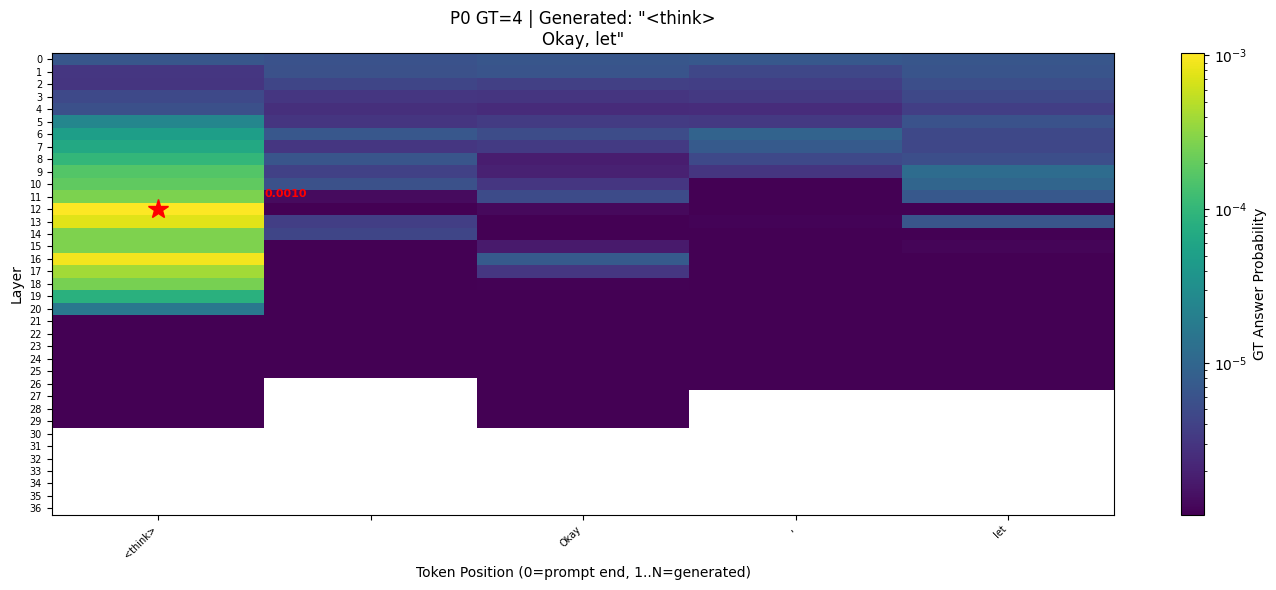

In [ ]:
def plot_gen_logit_lens(gen_results_list, gts, top_k=5):
    """Heatmap: rows=layers, cols=token positions, color=GT prob."""
    n_problems = len(gen_results_list)
    fig, axes = plt.subplots(n_problems, 1, figsize=(14, 6 * n_problems), squeeze=False)
    random_baseline = 1 / 23

    for idx, (gen_results, gt) in enumerate(zip(gen_results_list, gts)):
        ax = axes[idx, 0]
        n_positions = len(gen_results)
        n_layers = len(gen_results[0]["layers"])

        # Build matrix: [n_layers x n_positions]
        prob_matrix = np.zeros((n_layers, n_positions))
        for pos, pr in enumerate(gen_results):
            for lr in pr["layers"]:
                prob_matrix[lr["layer"], pos] = lr["gt_prob"]

        im = ax.imshow(prob_matrix, aspect="auto", cmap="viridis",
                      norm=plt.matplotlib.colors.LogNorm(vmin=max(prob_matrix.max()*0.001, 1e-6),
                                                       vmax=prob_matrix.max()))
        plt.colorbar(im, ax=ax, label="GT Answer Probability")

        # X-axis: token labels
        token_labels = [r["token"][:15] for r in gen_results]
        ax.set_xticks(range(n_positions))
        ax.set_xticklabels(token_labels, rotation=45, ha="right", fontsize=7)

        # Y-axis: layer labels
        layer_labels = [str(gen_results[0]["layers"][l]["layer"]) for l in range(n_layers)]
        ax.set_yticks(range(n_layers))
        ax.set_yticklabels(layer_labels, fontsize=7)

        ax.set_xlabel("Token Position (0=prompt end, 1..N=generated)")
        ax.set_ylabel("Layer")
        ax.set_title(f'P{idx} GT={gt} | Generated: "{gen_texts[idx][:60]}"')

        # Annotate peak
        peak_idx = np.unravel_index(prob_matrix.argmax(), prob_matrix.shape)
        ax.plot(peak_idx[1], peak_idx[0], 'r*', markersize=15)
        ax.annotate(f'{prob_matrix[peak_idx]:.4f}',
                    xy=peak_idx[::-1], xytext=(peak_idx[1]+0.5, peak_idx[0]-1),
                    fontsize=8, color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_gen_logit_lens(gen_all_results, gts, top_k=TOP_K)

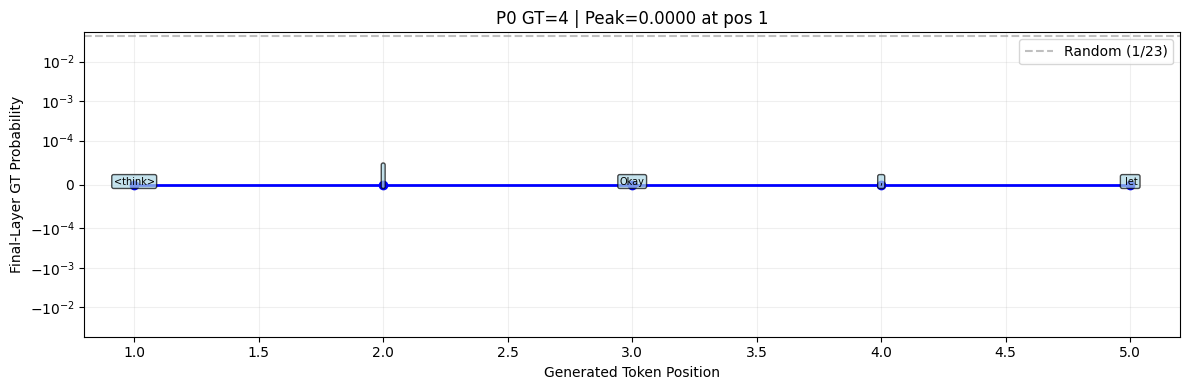

In [ ]:
# Also plot: final-layer GT prob vs generated token position (line plot)
fig, axes = plt.subplots(len(gts), 1, figsize=(12, 4 * len(gts)), squeeze=False)

for idx, (gen_results, gt) in enumerate(zip(gen_all_results, gts)):
    ax = axes[idx, 0]
    positions = [r["pos"] for r in gen_results]
    final_probs = [r["layers"][-1]["gt_prob"] for r in gen_results]
    tokens_at_pos = [r["token"] for r in gen_results]

    ax.plot(positions, final_probs, 'b-o', linewidth=2, markersize=6)
    ax.axhline(1/23, color='gray', linestyle='--', alpha=0.5, label='Random (1/23)')

    # Annotate each point with its token
    for pos, prob, tok in zip(positions, final_probs, tokens_at_pos):
        ax.annotate(tok[:10], xy=(pos, prob), xytext=(pos, prob + max(final_probs)*0.1),
                    fontsize=7, ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))

    best_p = max(final_probs)
    best_pos = positions[final_probs.index(best_p)]
    ax.set_title(f'P{idx} GT={gt} | Peak={best_p:.4f} at pos {best_pos}')
    ax.set_xlabel('Generated Token Position')
    ax.set_ylabel('Final-Layer GT Probability')
    ax.legend()
    ax.grid(alpha=0.2)
    ax.set_yscale('symlog', linthresh=1e-4)

plt.tight_layout()
plt.show()

In [ ]:
# Detailed table: GT prob at every (layer, position) for each problem
for idx, (gen_results, gt) in enumerate(zip(gen_all_results, gts)):
    print(f"\n{'='*100}")
    print(f'Problem {idx} (GT={gt}) | Generated: "{gen_texts[idx]}"')
    print(f"{'Position':>8} {'Token':>12}", end='')
    for r in gen_results[0]['layers']:
        print(f" L{r['layer']:>9}", end='')
    print(f" | {'Top-1 Token':>20}")
    print('-' * 140)
    for pr in gen_results:
        print(f"{pr['pos']:>8} {pr['token']:>12}", end='')
        for lr in pr['layers']:
            print(f" {lr['gt_prob']:>9.4f}", end='')
        top1_tok, top1_prob = pr['layers'][-1]['top_tokens'][0]
        print(f" | {top1_tok:>15} ({top1_prob:.3f})")


Problem 0 (GT=4) | Generated: "<think>
Okay, let"
Position        Token L        0 L        1 L        2 L        3 L        4 L        5 L        6 L        7 L        8 L        9 L       10 L       11 L       12 L       13 L       14 L       15 L       16 L       17 L       18 L       19 L       20 L       21 L       22 L       23 L       24 L       25 L       26 L       27 L       28 L       29 L       30 L       31 L       32 L       33 L       34 L       35 L       36 |          Top-1 Token
--------------------------------------------------------------------------------------------------------------------------------------------
       1      <think>    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0001    0.0001    0.0001    0.0002    0.0002    0.0003    0.0010    0.0008    0.0003    0.0003    0.0009    0.0004    0.0002    0.0001    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0

In [ ]:
for idx, (results, gt) in enumerate(zip(all_results, gts)):
    print(f"\n{'='*80}")
    print(f'Problem {idx} (GT={gt}) | token="{results[0]["gt_token_str"]}" | cache={all_cache_paths[idx]}')
    print(f"{'Layer':>6} {'GT Prob':>10} {'GT Logit':>12} | Top-{TOP_K}")
    print("-" * 80)
    for r in results:
        top_str = ", ".join([f"{t}({p:.3f})" for t, p in r["top_tokens"]])
        print(f"{r['layer']:>6} {r['gt_prob']:>10.4f} {r['gt_logit']:>12.2f} | {top_str}")


Problem 0 (GT=4) | token="2" | cache=logit_lens_caches/p_gt22.pt
 Layer    GT Prob     GT Logit | Top-3
--------------------------------------------------------------------------------
     0     0.0000        -0.06 | 䗪(0.000), 白癜(0.000), 蔊(0.000)
     1     0.0000        -0.28 |  coquine(0.000), 挓(0.000), 䗪(0.000)
     2     0.0000        -0.29 |  coquine(0.000),  Annunci(0.000),  Sesso(0.000)
     3     0.0000        -0.95 |  coquine(0.000),  Sesso(0.000), nehmer(0.000)
     4     0.0000        -0.74 |  coquine(0.000), nehmer(0.000),  Sesso(0.000)
     5     0.0000        -0.12 | nehmer(0.000), ../../../(0.000), orthand(0.000)
     6     0.0000         1.38 | 前提是(0.000), orthand(0.000), ../../../(0.000)
     7     0.0000         0.13 | 前提是(0.001), abox(0.001), 的前提(0.000)
     8     0.0000         0.56 | 的前提(0.004), 正确的(0.002), 先把(0.001)
     9     0.0000         0.45 | 的前提(0.003), 首先要(0.001), 这个职业(0.001)
    10     0.0000         1.16 | 正确的(0.007), 先把(0.003), 首先(0.003)
    11     0.

## Reload Caches for Further Analysis

Caches are saved as `.pt` files in `logit_lens_caches/`. You can reload them
without re-running the forward pass:

In [ ]:
def load_cache(cache_name):
    """Load a saved ActivationCache from disk."""
    cache_path = os.path.join(CACHE_DIR, f"{cache_name}.pt")
    return torch.load(cache_path, weights_only=False)

def analyze_cache(cache, model, gt, layer_indices=None):
    """Run arbitrary analysis on a loaded cache.

    Args:
        cache: ActivationCache from load_cache()
        model: HookedTransformer
        gt: ground truth answer int
        layer_indices: specific layers to analyze (default: all)
    """
    n_layers = model.cfg.n_layers
    last_pos = cache["resid_post", 0].shape[1] - 1

    gt_tokens = model.to_tokens(str(gt))
    gt_token_id = gt_tokens[0, 1].item() if gt_tokens.shape[1] == 2 else gt_tokens[0, 0].item()

    if layer_indices is None:
        layer_indices = list(range(n_layers + 1))

    results = {}
    for layer_idx in layer_indices:
        if layer_idx == 0:
            resid = cache["resid_pre", 0][0, last_pos]
        else:
            resid = cache["resid_post", layer_idx - 1][0, last_pos]
        logits = resid @ model.W_U
        probs = logits.softmax(dim=-1)
        results[layer_idx] = {
            "resid": resid.detach().cpu(),
            "logits": logits.detach().cpu(),
            "probs": probs.detach().cpu(),
            "gt_prob": probs[gt_token_id].item(),
            "gt_logit": logits[gt_token_id].item(),
        }
    return results

In [ ]:
# Example: reload a cache and inspect the residual stream at a specific layer
cache_22 = load_cache("p_gt22")
analysis = analyze_cache(cache_22, model, gt=22, layer_indices=[0, 10, 20, 28, 35])

for layer_idx, data in analysis.items():
    print(f"Layer {layer_idx}: GT prob={data['gt_prob']:.4f}, GT logit={data['gt_logit']:.2f}")
    print(f"  resid norm: {data['resid'].norm():.2f}")
    print(f"  resid mean: {data['resid'].mean():.4f}, std: {data['resid'].std():.4f}")

Layer 0: GT prob=0.0000, GT logit=-0.06
  resid norm: 1.51
  resid mean: -0.0001, std: 0.0236
Layer 10: GT prob=0.0000, GT logit=1.16
  resid norm: 42.28
  resid mean: 0.0163, std: 0.6606
Layer 20: GT prob=0.0000, GT logit=2.97
  resid norm: 87.79
  resid mean: 0.0057, std: 1.3719
Layer 28: GT prob=0.0000, GT logit=-39.34
  resid norm: 323.37
  resid mean: -0.0929, std: 5.0524
Layer 35: GT prob=0.0000, GT logit=33.66
  resid norm: 1178.34
  resid mean: 0.0140, std: 18.4138


In [ ]:
# List all saved caches
saved = sorted(glob.glob(os.path.join(CACHE_DIR, "*.pt")))
print(f"Saved caches in {CACHE_DIR}/:")
for p in saved:
    size_mb = os.path.getsize(p) / 1e6
    print(f"  {os.path.basename(p)} ({size_mb:.1f} MB)")

Saved caches in logit_lens_caches/:
  p_gt12.pt (41181.9 MB)
  p_gt22.pt (34495.3 MB)
